In [37]:
import matplotlib.pyplot as plt
from price.shared import get_prices_by_ram_type
from datetime import date
from price.data import load_all_data
from datetime import date

[GenericData(title='ACER BL.9BWWA.436', price='6639000', detail=None), GenericData(title='ACER BL.9BWWA.437 | HT200 32GB (2x16GB) DDR5 DRAM 5600MHz CL40 AMD EXPO & Intel XMP Memory Kit - Black', price='6649000', detail=None), GenericData(title='BIWIN BD5UD16G56C46', price='3479000', detail=None), GenericData(title='BIWIN BD5UD32G56C46', price='6639000', detail=None), GenericData(title='BIWIN Black Opal DW100 DDR5 RGB 64GB Kit (2 x 32GB) 6000 MT/s CL30 Black', price='15309000', detail='Desktop Memory, Black Opal DW100 DDR5 RGB, 64GB (2x32GB), PC5-48000 (DDR5-6000), CL 30, 1.35V, Intel XMP 3.0 & AMD EXPO Profile Ready'), GenericData(title='BIWIN Black Opal DW100 DDR5 RGB 64GB Kit (2 x 32GB) 6000 MT/s CL30 White', price='15309000', detail='Desktop Memory, Black Opal DW100 DDR5 RGB, 64GB (2x32GB), PC5-48000 (DDR5-6000), CL 30, 1.35V, Intel XMP 3.0 & AMD EXPO Profile Ready'), GenericData(title='BIWIN BXH53260HX1-D36DB', price='7149000', detail=None), GenericData(title='BIWIN BXH53260HX1-D36

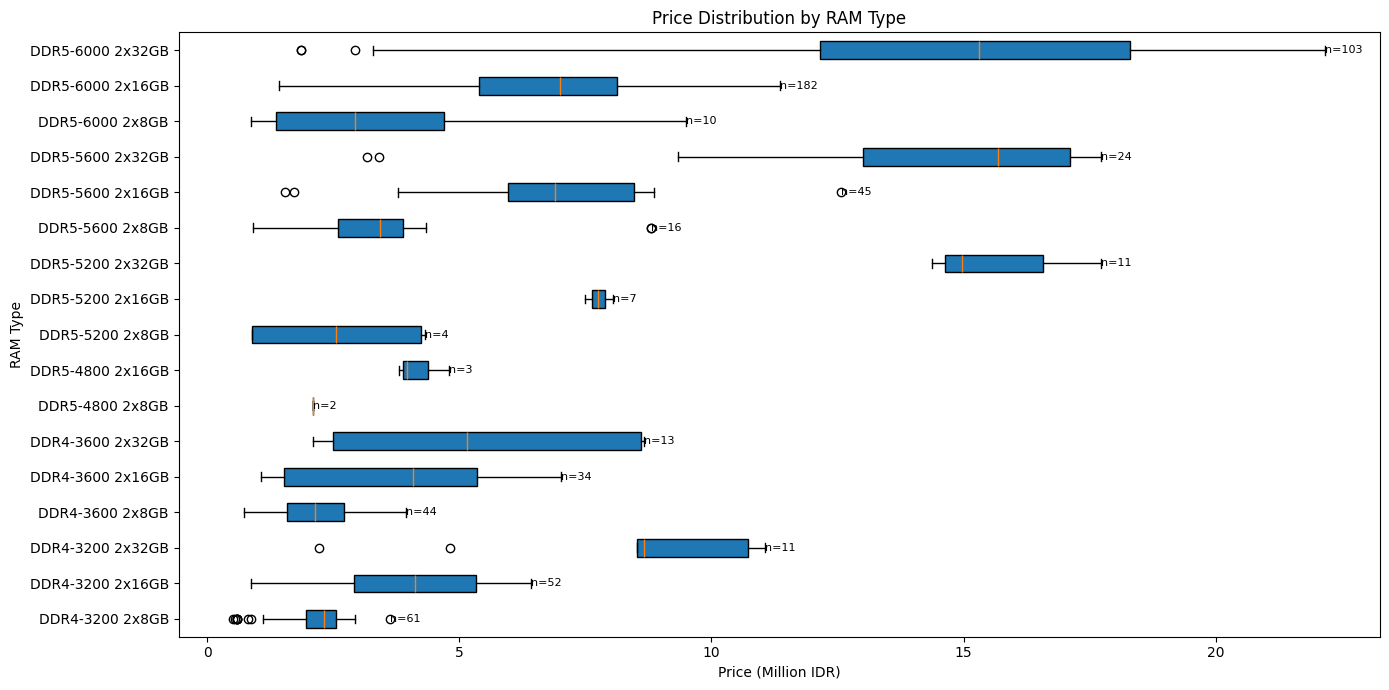

In [38]:
from price.shared import ProductCategory, ProductInfo, result_to_product_info
import re

prods = load_all_data(date.today())[ProductCategory.RAM]
prodinfos = map(lambda x: result_to_product_info(x.title + " " + (x.detail or ""), ProductCategory.RAM, int(x.price)), prods)
infos: list[ProductInfo] = list(filter(lambda x: x is not None, prodinfos)) # type: ignore

print(prods)

prices_by_type = get_prices_by_ram_type(infos)

def ram_sort_key(t):
    m = re.match(r'DDR(\d)-(\d+) (\d+)x(\d+)GB', t.value)
    gen, speed, count, size = int(m[1]), int(m[2]), int(m[3]), int(m[4])
    total = count * size
    return (gen, speed, total)

sorted_types = sorted(prices_by_type.keys(), key=ram_sort_key)
labels = [t.value for t in sorted_types]
box_data = [prices_by_type[t] for t in sorted_types]

box_data = [[p / 1e6 for p in prices] for prices in box_data]

print(labels, box_data)
fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("RAM Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by RAM Type")

for i, t in enumerate(sorted_types):
    ax.annotate(
        f"n={len(prices_by_type[t])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

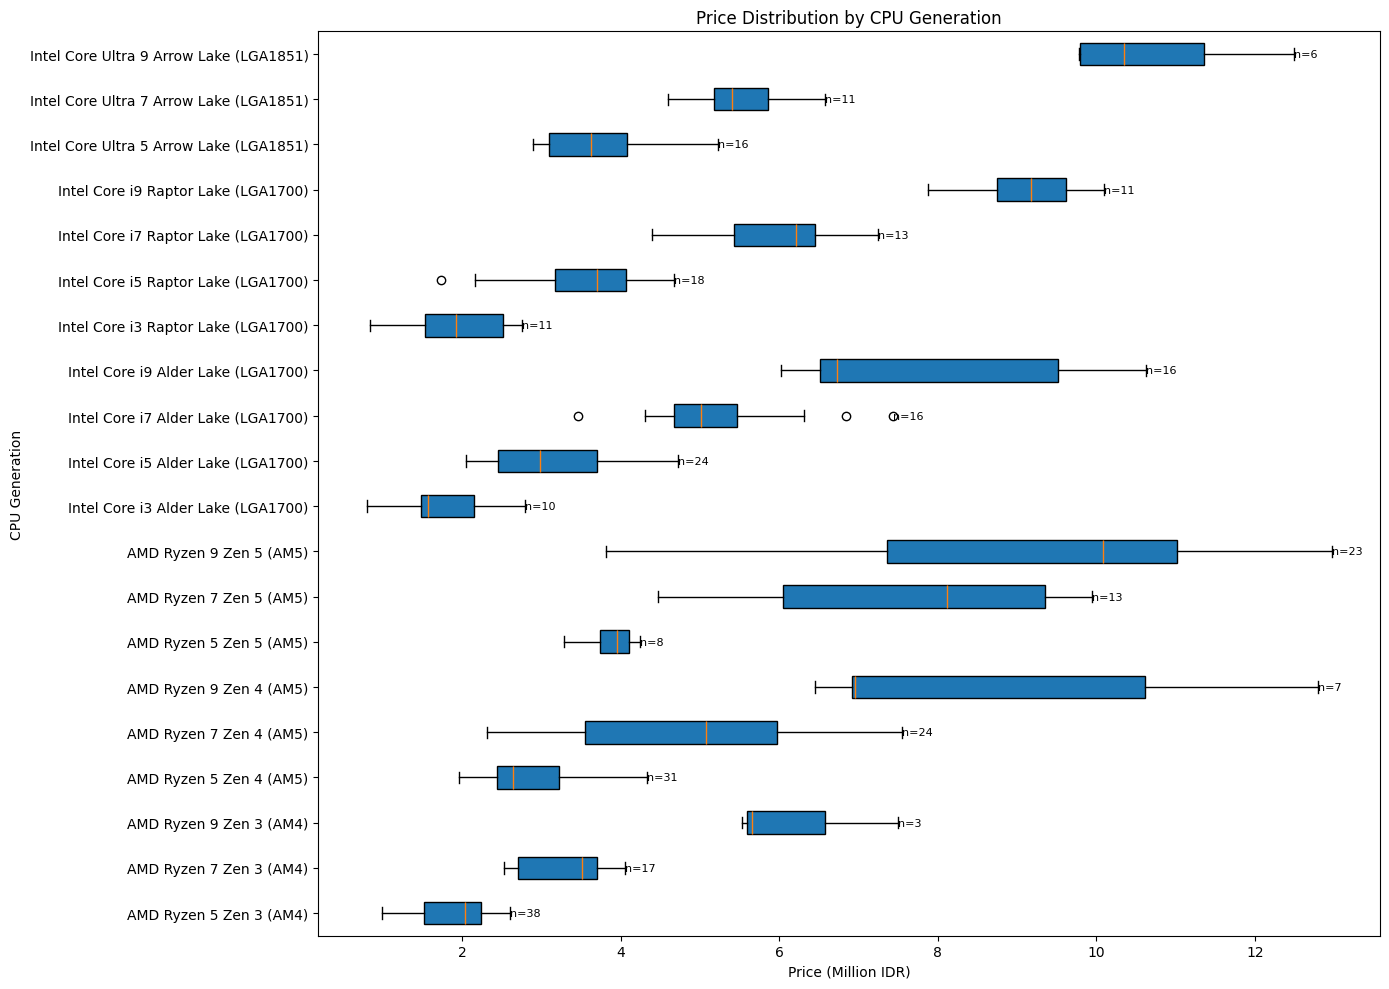

In [39]:
from collections import defaultdict
from price.shared import (
    ProductCategory, ProductInfo, result_to_product_info,
    CPUGeneration, CPUInfo, Brand
)
import re

prods = load_all_data(date.today())[ProductCategory.PROCESSOR]

def get_cpu_tier(title):
    if re.search(r'Core Ultra 9', title, re.IGNORECASE):
        return 'Core Ultra 9'
    if re.search(r'Core Ultra 7', title, re.IGNORECASE):
        return 'Core Ultra 7'
    if re.search(r'Core Ultra 5', title, re.IGNORECASE):
        return 'Core Ultra 5'
    if re.search(r'Ryzen 9', title, re.IGNORECASE):
        return 'Ryzen 9'
    if re.search(r'Ryzen 7', title, re.IGNORECASE):
        return 'Ryzen 7'
    if re.search(r'Ryzen 5', title, re.IGNORECASE):
        return 'Ryzen 5'
    if re.search(r'i9[- ]', title) or re.search(r'Core i9', title, re.IGNORECASE):
        return 'Core i9'
    if re.search(r'i7[- ]', title) or re.search(r'Core i7', title, re.IGNORECASE):
        return 'Core i7'
    if re.search(r'i5[- ]', title) or re.search(r'Core i5', title, re.IGNORECASE):
        return 'Core i5'
    if re.search(r'i3[- ]', title) or re.search(r'Core i3', title, re.IGNORECASE):
        return 'Core i3'
    return None

GEN_LABELS = {
    CPUGeneration.AMD_AM4: "Zen 3 (AM4)",
    CPUGeneration.AMD_AM5_Zen4: "Zen 4 (AM5)",
    CPUGeneration.AMD_AM5_Zen5: "Zen 5 (AM5)",
    CPUGeneration.Intel_LGA1700_AlderLake: "Alder Lake (LGA1700)",
    CPUGeneration.Intel_LGA1700_RaptorLake: "Raptor Lake (LGA1700)",
    CPUGeneration.Intel_LGA1851: "Arrow Lake (LGA1851)",
}

CPU_CATEGORIES = [
    "AMD Ryzen 5 Zen 3 (AM4)",
    "AMD Ryzen 7 Zen 3 (AM4)",
    "AMD Ryzen 9 Zen 3 (AM4)",
    "AMD Ryzen 5 Zen 4 (AM5)",
    "AMD Ryzen 7 Zen 4 (AM5)",
    "AMD Ryzen 9 Zen 4 (AM5)",
    "AMD Ryzen 5 Zen 5 (AM5)",
    "AMD Ryzen 7 Zen 5 (AM5)",
    "AMD Ryzen 9 Zen 5 (AM5)",
    "Intel Core i3 Alder Lake (LGA1700)",
    "Intel Core i5 Alder Lake (LGA1700)",
    "Intel Core i7 Alder Lake (LGA1700)",
    "Intel Core i9 Alder Lake (LGA1700)",
    "Intel Core i3 Raptor Lake (LGA1700)",
    "Intel Core i5 Raptor Lake (LGA1700)",
    "Intel Core i7 Raptor Lake (LGA1700)",
    "Intel Core i9 Raptor Lake (LGA1700)",
    "Intel Core Ultra 5 Arrow Lake (LGA1851)",
    "Intel Core Ultra 7 Arrow Lake (LGA1851)",
    "Intel Core Ultra 9 Arrow Lake (LGA1851)",
]

prices_by_cpu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    info = result_to_product_info(title, ProductCategory.PROCESSOR, int(x.price))
    if info is None or not isinstance(info.details, CPUInfo):
        continue
    tier = get_cpu_tier(title)
    if tier is None:
        continue
    gen_label = GEN_LABELS.get(info.details.generation, "")
    brand_label = "AMD" if info.details.brand == Brand.AMD else "Intel"
    label = f"{brand_label} {tier} {gen_label}"
    if label in CPU_CATEGORIES:
        prices_by_cpu[label].append(info.price)

labels = [c for c in CPU_CATEGORIES if c in prices_by_cpu]
box_data = [[p / 1e6 for p in prices_by_cpu[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 10))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("CPU Generation")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by CPU Generation")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_cpu[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

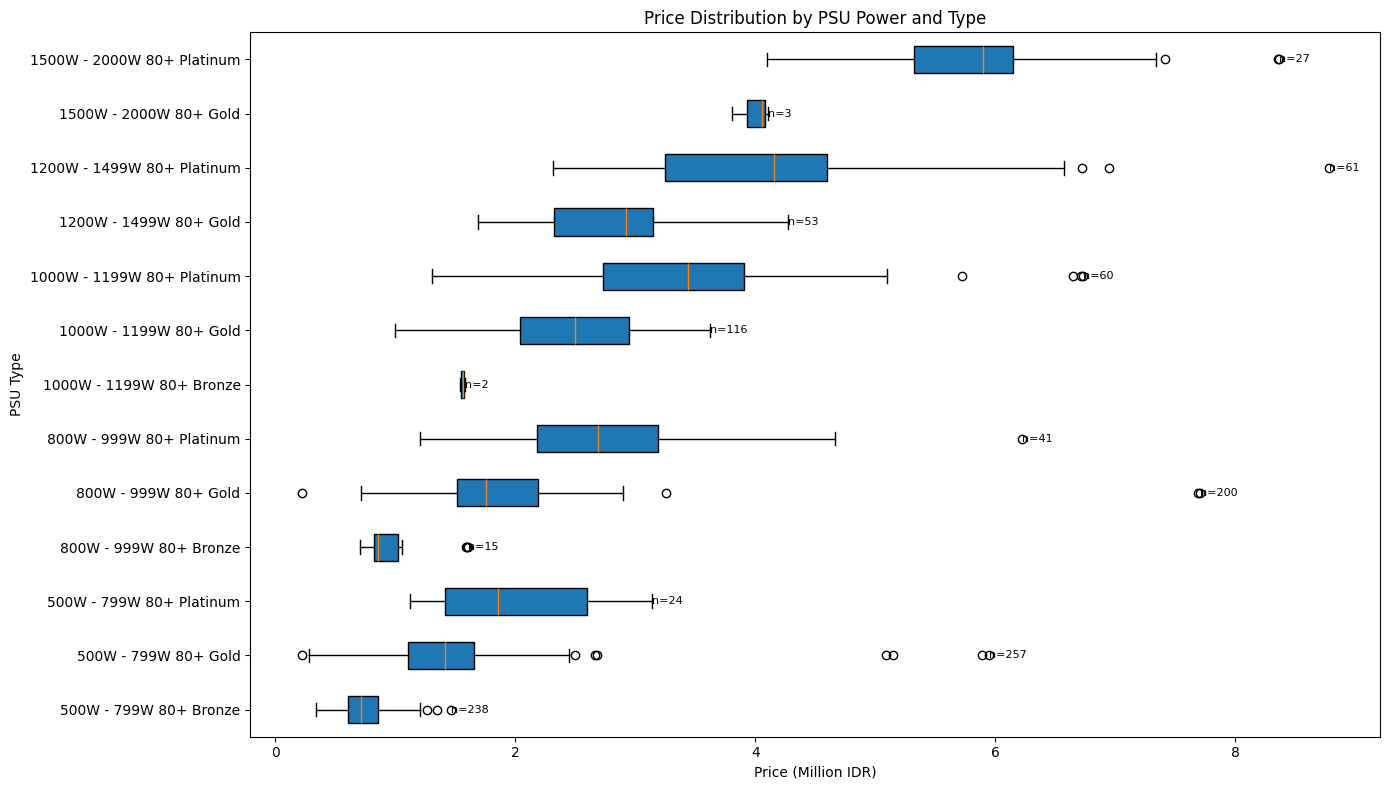

In [40]:
from collections import defaultdict
from price.shared import (
    ProductCategory, result_to_product_info, PSUInfo, PSUType, PSUPower
)

prods = load_all_data(date.today())[ProductCategory.PSU]

PSU_CATEGORIES = [
    "500W - 799W 80+ Bronze",
    "500W - 799W 80+ Gold",
    "500W - 799W 80+ Platinum",
    "800W - 999W 80+ Bronze",
    "800W - 999W 80+ Gold",
    "800W - 999W 80+ Platinum",
    "1000W - 1199W 80+ Bronze",
    "1000W - 1199W 80+ Gold",
    "1000W - 1199W 80+ Platinum",
    "1200W - 1499W 80+ Gold",
    "1200W - 1499W 80+ Platinum",
    "1500W - 2000W 80+ Gold",
    "1500W - 2000W 80+ Platinum",
]

prices_by_psu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    info = result_to_product_info(title, ProductCategory.PSU, int(x.price))
    if info is None or not isinstance(info.details, PSUInfo):
        continue
    try:
        power_range = info.details.power_range
    except ValueError:
        continue
    label = f"{power_range.value} 80+ {info.details.psu_type.value}"
    if label in PSU_CATEGORIES:
        prices_by_psu[label].append(info.price)

labels = [c for c in PSU_CATEGORIES if c in prices_by_psu]
box_data = [[p / 1e6 for p in prices_by_psu[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 8))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("PSU Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by PSU Power and Type")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_psu[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

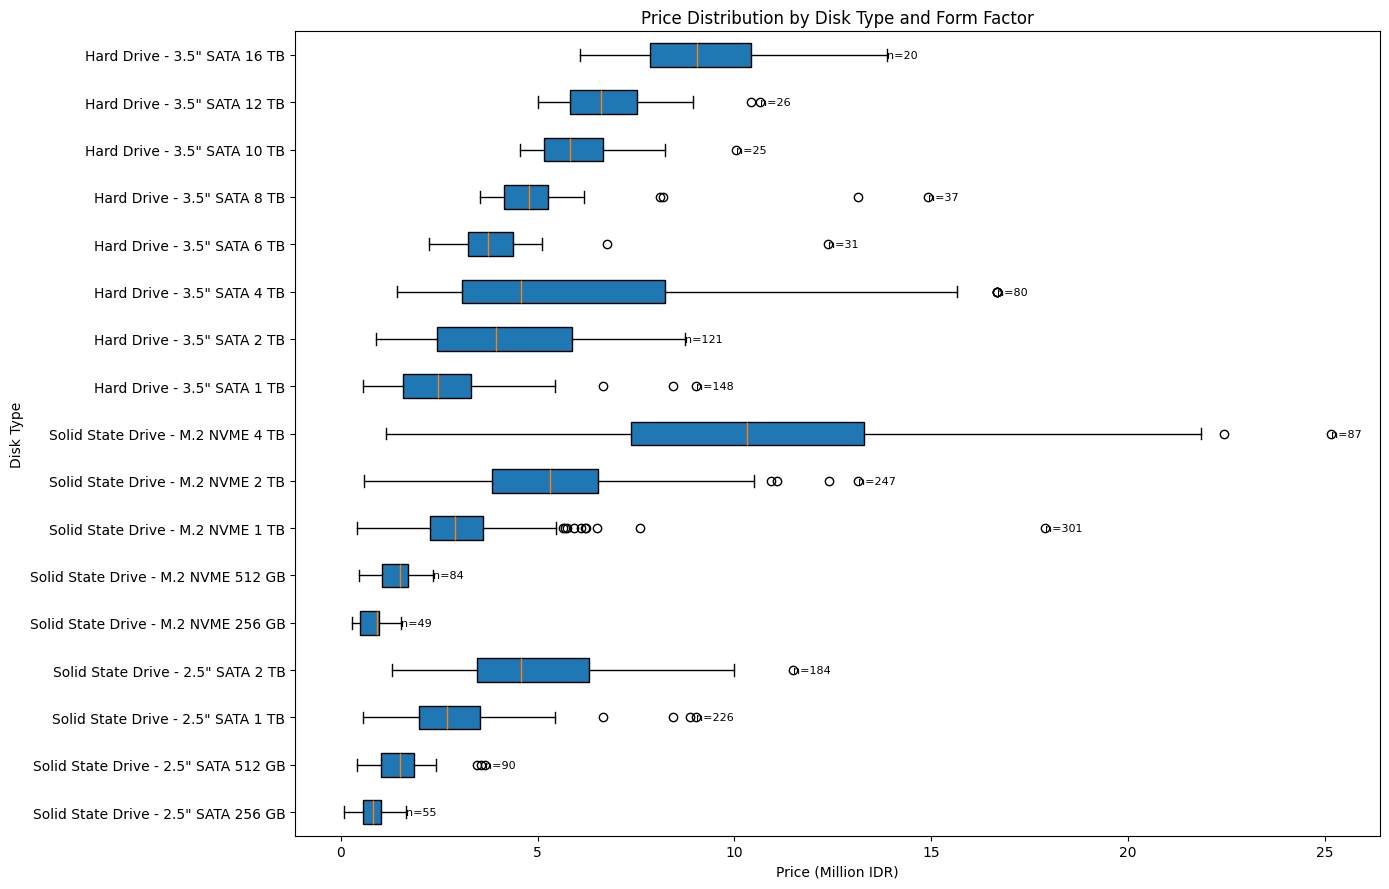

In [41]:
from collections import defaultdict
from price.shared import (
    ProductCategory, result_to_product_info, DiskInfo, DiskType, FormFactor
)

ssd_prods = load_all_data(date.today())[ProductCategory.SSD]
hdd_prods = load_all_data(date.today())[ProductCategory.HARDDISK]

def format_capacity(capacity_gb):
    if capacity_gb >= 1000:
        return f"{capacity_gb // 1000} TB"
    return f"{capacity_gb} GB"

DISK_TYPE_LABELS = {
    DiskType.SSD: "Solid State Drive",
    DiskType.HDD: "Hard Drive",
}

DISK_CATEGORIES = [
    'Solid State Drive - 2.5" SATA 256 GB',
    'Solid State Drive - 2.5" SATA 512 GB',
    'Solid State Drive - 2.5" SATA 1 TB',
    'Solid State Drive - 2.5" SATA 2 TB',
    "Solid State Drive - M.2 NVME 256 GB",
    "Solid State Drive - M.2 NVME 512 GB",
    "Solid State Drive - M.2 NVME 1 TB",
    "Solid State Drive - M.2 NVME 2 TB",
    "Solid State Drive - M.2 NVME 4 TB",
    'Hard Drive - 3.5" SATA 1 TB',
    'Hard Drive - 3.5" SATA 2 TB',
    'Hard Drive - 3.5" SATA 4 TB',
    'Hard Drive - 3.5" SATA 6 TB',
    'Hard Drive - 3.5" SATA 8 TB',
    'Hard Drive - 3.5" SATA 10 TB',
    'Hard Drive - 3.5" SATA 12 TB',
    'Hard Drive - 3.5" SATA 16 TB',
]

prices_by_disk = defaultdict(list)
for cat, prods in [(ProductCategory.SSD, ssd_prods), (ProductCategory.HARDDISK, hdd_prods)]:
    for x in prods:
        title = x.title + " " + (x.detail or "")
        info = result_to_product_info(title, cat, int(x.price))
        if info is None or not isinstance(info.details, DiskInfo):
            continue
        d = info.details
        type_label = DISK_TYPE_LABELS[d.disk_type]
        label = f"{type_label} - {d.form_factor.value} {format_capacity(d.capacity_gb)}"
        if label in DISK_CATEGORIES:
            prices_by_disk[label].append(info.price)

labels = [c for c in DISK_CATEGORIES if c in prices_by_disk]
box_data = [[p / 1e6 for p in prices_by_disk[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 9))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("Disk Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by Disk Type and Form Factor")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_disk[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

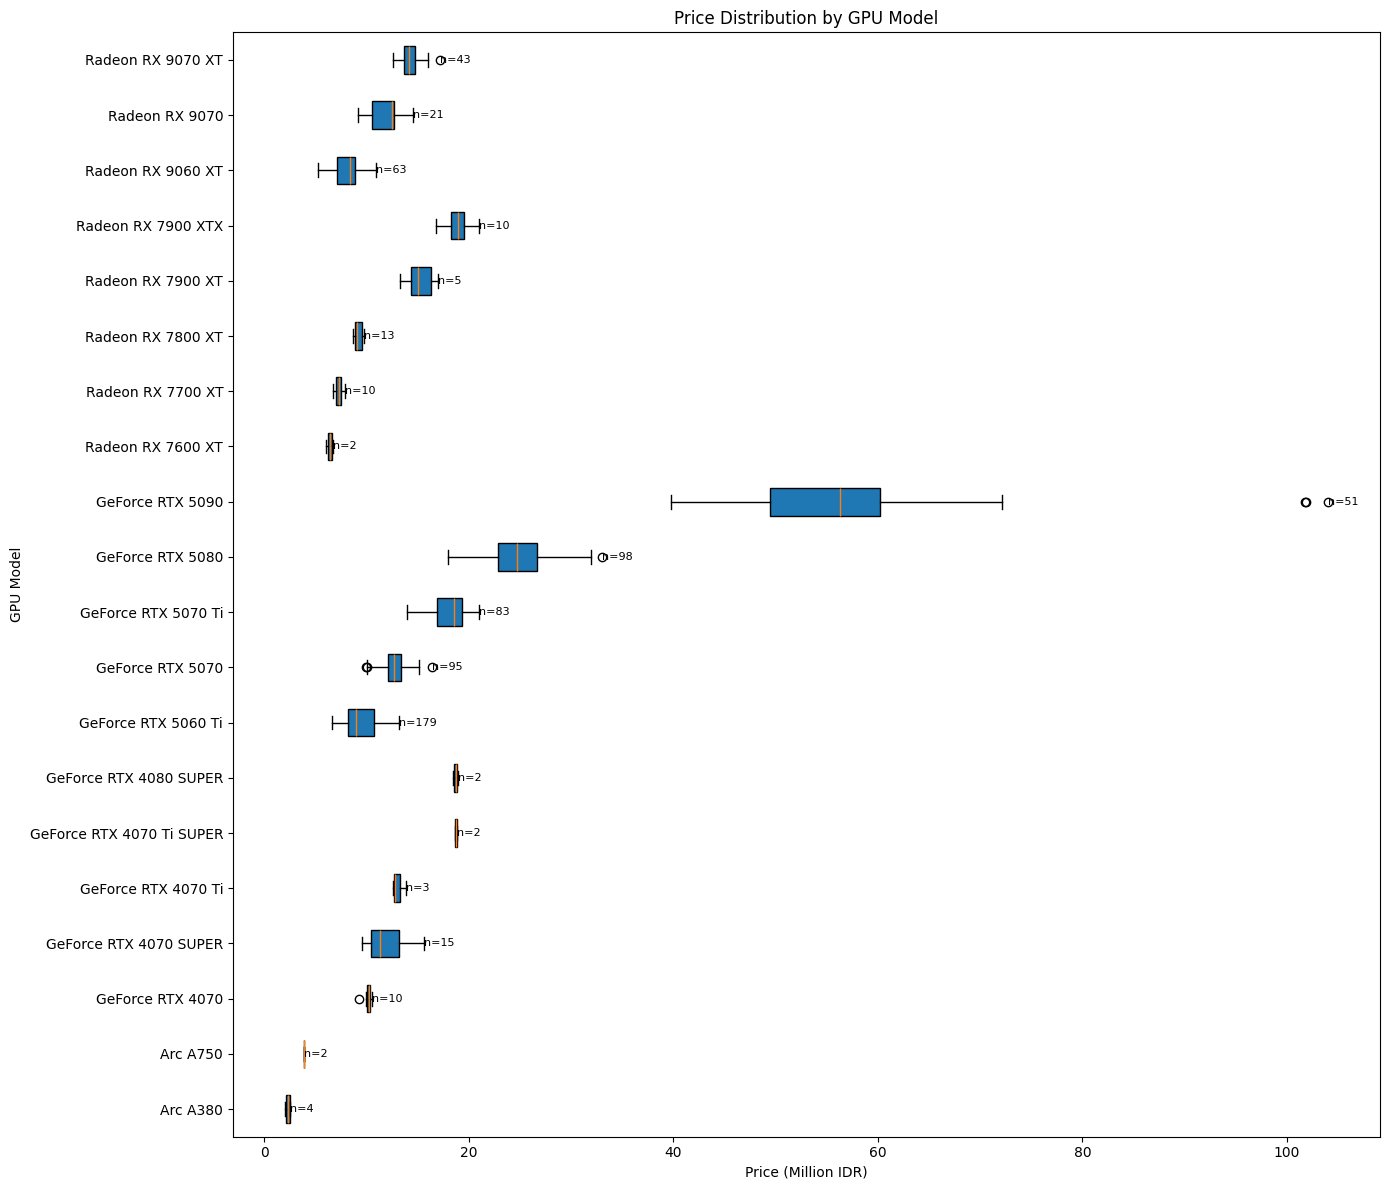

In [42]:
from collections import defaultdict
from price.shared import ProductCategory
import re

prods = load_all_data(date.today())[ProductCategory.VGA]

GPU_MODELS = [
    "GeForce RTX 4070 Ti SUPER",
    "GeForce RTX 4070 Ti",
    "GeForce RTX 4070 SUPER",
    "GeForce RTX 4070",
    "GeForce RTX 4080 SUPER",
    "GeForce RTX 4080",
    "GeForce RTX 4090",
    "GeForce RTX 5060 Ti",
    "GeForce RTX 5070 Ti",
    "GeForce RTX 5070",
    "GeForce RTX 5080",
    "GeForce RTX 5090",
    "Radeon RX 7600 XT",
    "Radeon RX 7700 XT",
    "Radeon RX 7800 XT",
    "Radeon RX 7900 XTX",
    "Radeon RX 7900 XT",
    "Radeon RX 9060 XT",
    "Radeon RX 9070 XT",
    "Radeon RX 9070",
    "Arc A770",
    "Arc A750",
    "Arc A380",
]

GPU_DISPLAY_ORDER = [
    "Arc A380",
    "Arc A750",
    "Arc A770",
    "GeForce RTX 4070",
    "GeForce RTX 4070 SUPER",
    "GeForce RTX 4070 Ti",
    "GeForce RTX 4070 Ti SUPER",
    "GeForce RTX 4080",
    "GeForce RTX 4080 SUPER",
    "GeForce RTX 4090",
    "GeForce RTX 5060 Ti",
    "GeForce RTX 5070",
    "GeForce RTX 5070 Ti",
    "GeForce RTX 5080",
    "GeForce RTX 5090",
    "Radeon RX 7600 XT",
    "Radeon RX 7700 XT",
    "Radeon RX 7800 XT",
    "Radeon RX 7900 XT",
    "Radeon RX 7900 XTX",
    "Radeon RX 9060 XT",
    "Radeon RX 9070",
    "Radeon RX 9070 XT",
]

def get_gpu_category(title):
    title_lower = title.lower()
    for model in GPU_MODELS:
        if model.lower() in title_lower:
            return model
    return None

prices_by_gpu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    model = get_gpu_category(title)
    if model is None:
        continue
    prices_by_gpu[model].append(int(x.price))

labels = [c for c in GPU_DISPLAY_ORDER if c in prices_by_gpu]
box_data = [[p / 1e6 for p in prices_by_gpu[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 12))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("GPU Model")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by GPU Model")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_gpu[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

In [43]:
from pathlib import Path
from datetime import date
from statistics import median, quantiles
from collections import defaultdict
from price.data import load_all_data
from price.shared import (
    ProductCategory, ProductInfo, result_to_product_info,
    CPUGeneration, CPUInfo, Brand,
    PSUInfo, PSUType, PSUPower,
    DiskInfo, DiskType, FormFactor,
    RAMType, RAMInfo,
)
from price.source.generic import GenericData
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

# Discover all date directories and sort them
data_dir = Path("data")
date_dirs = sorted(d.name for d in data_dir.iterdir() if d.is_dir())
dates = [date.fromisoformat(d) for d in date_dirs]

# Pre-load all data for each date
all_data_by_date = {}
for dt in dates:
    all_data_by_date[dt] = load_all_data(dt)

print(dates)

def plot_historical_trend(dates, medians_by_subcategory, q1_by_subcategory, q3_by_subcategory, subcategory_order, title, ylabel):
    active_labels = [l for l in subcategory_order if l in medians_by_subcategory and any(v is not None for v in medians_by_subcategory[l])]
    if not active_labels:
        return
    n = len(active_labels)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)
    fig.suptitle(title, fontsize=14)
    for idx, label in enumerate(active_labels):
        r, c = divmod(idx, cols)
        ax = axes[r][c]
        vals = medians_by_subcategory[label]
        q1_vals = q1_by_subcategory[label]
        q3_vals = q3_by_subcategory[label]
        plot_dates = [d for d, v in zip(dates, vals) if v is not None]
        plot_vals = [v for v in vals if v is not None]
        plot_q1 = [q for q, v in zip(q1_vals, vals) if v is not None]
        plot_q3 = [q for q, v in zip(q3_vals, vals) if v is not None]
        if plot_vals:
            ax.plot(plot_dates, plot_vals, marker='o', color='tab:blue')
            ax.fill_between(plot_dates, plot_q1, plot_q3, alpha=0.2, color='gray')
            all_vals = plot_vals + plot_q1 + plot_q3
            ymin, ymax = min(all_vals), max(all_vals)
            margin = max((ymax - ymin) * 0.3, ymax * 0.1)
            ax.set_ylim(max(0, ymin - margin), ymax + margin)
        ax.set_title(label, fontsize=9)
        ax.set_ylabel('Million IDR', fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, alpha=0.3)
    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r][c].set_visible(False)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

[datetime.date(2026, 2, 25), datetime.date(2026, 2, 27), datetime.date(2026, 3, 1)]


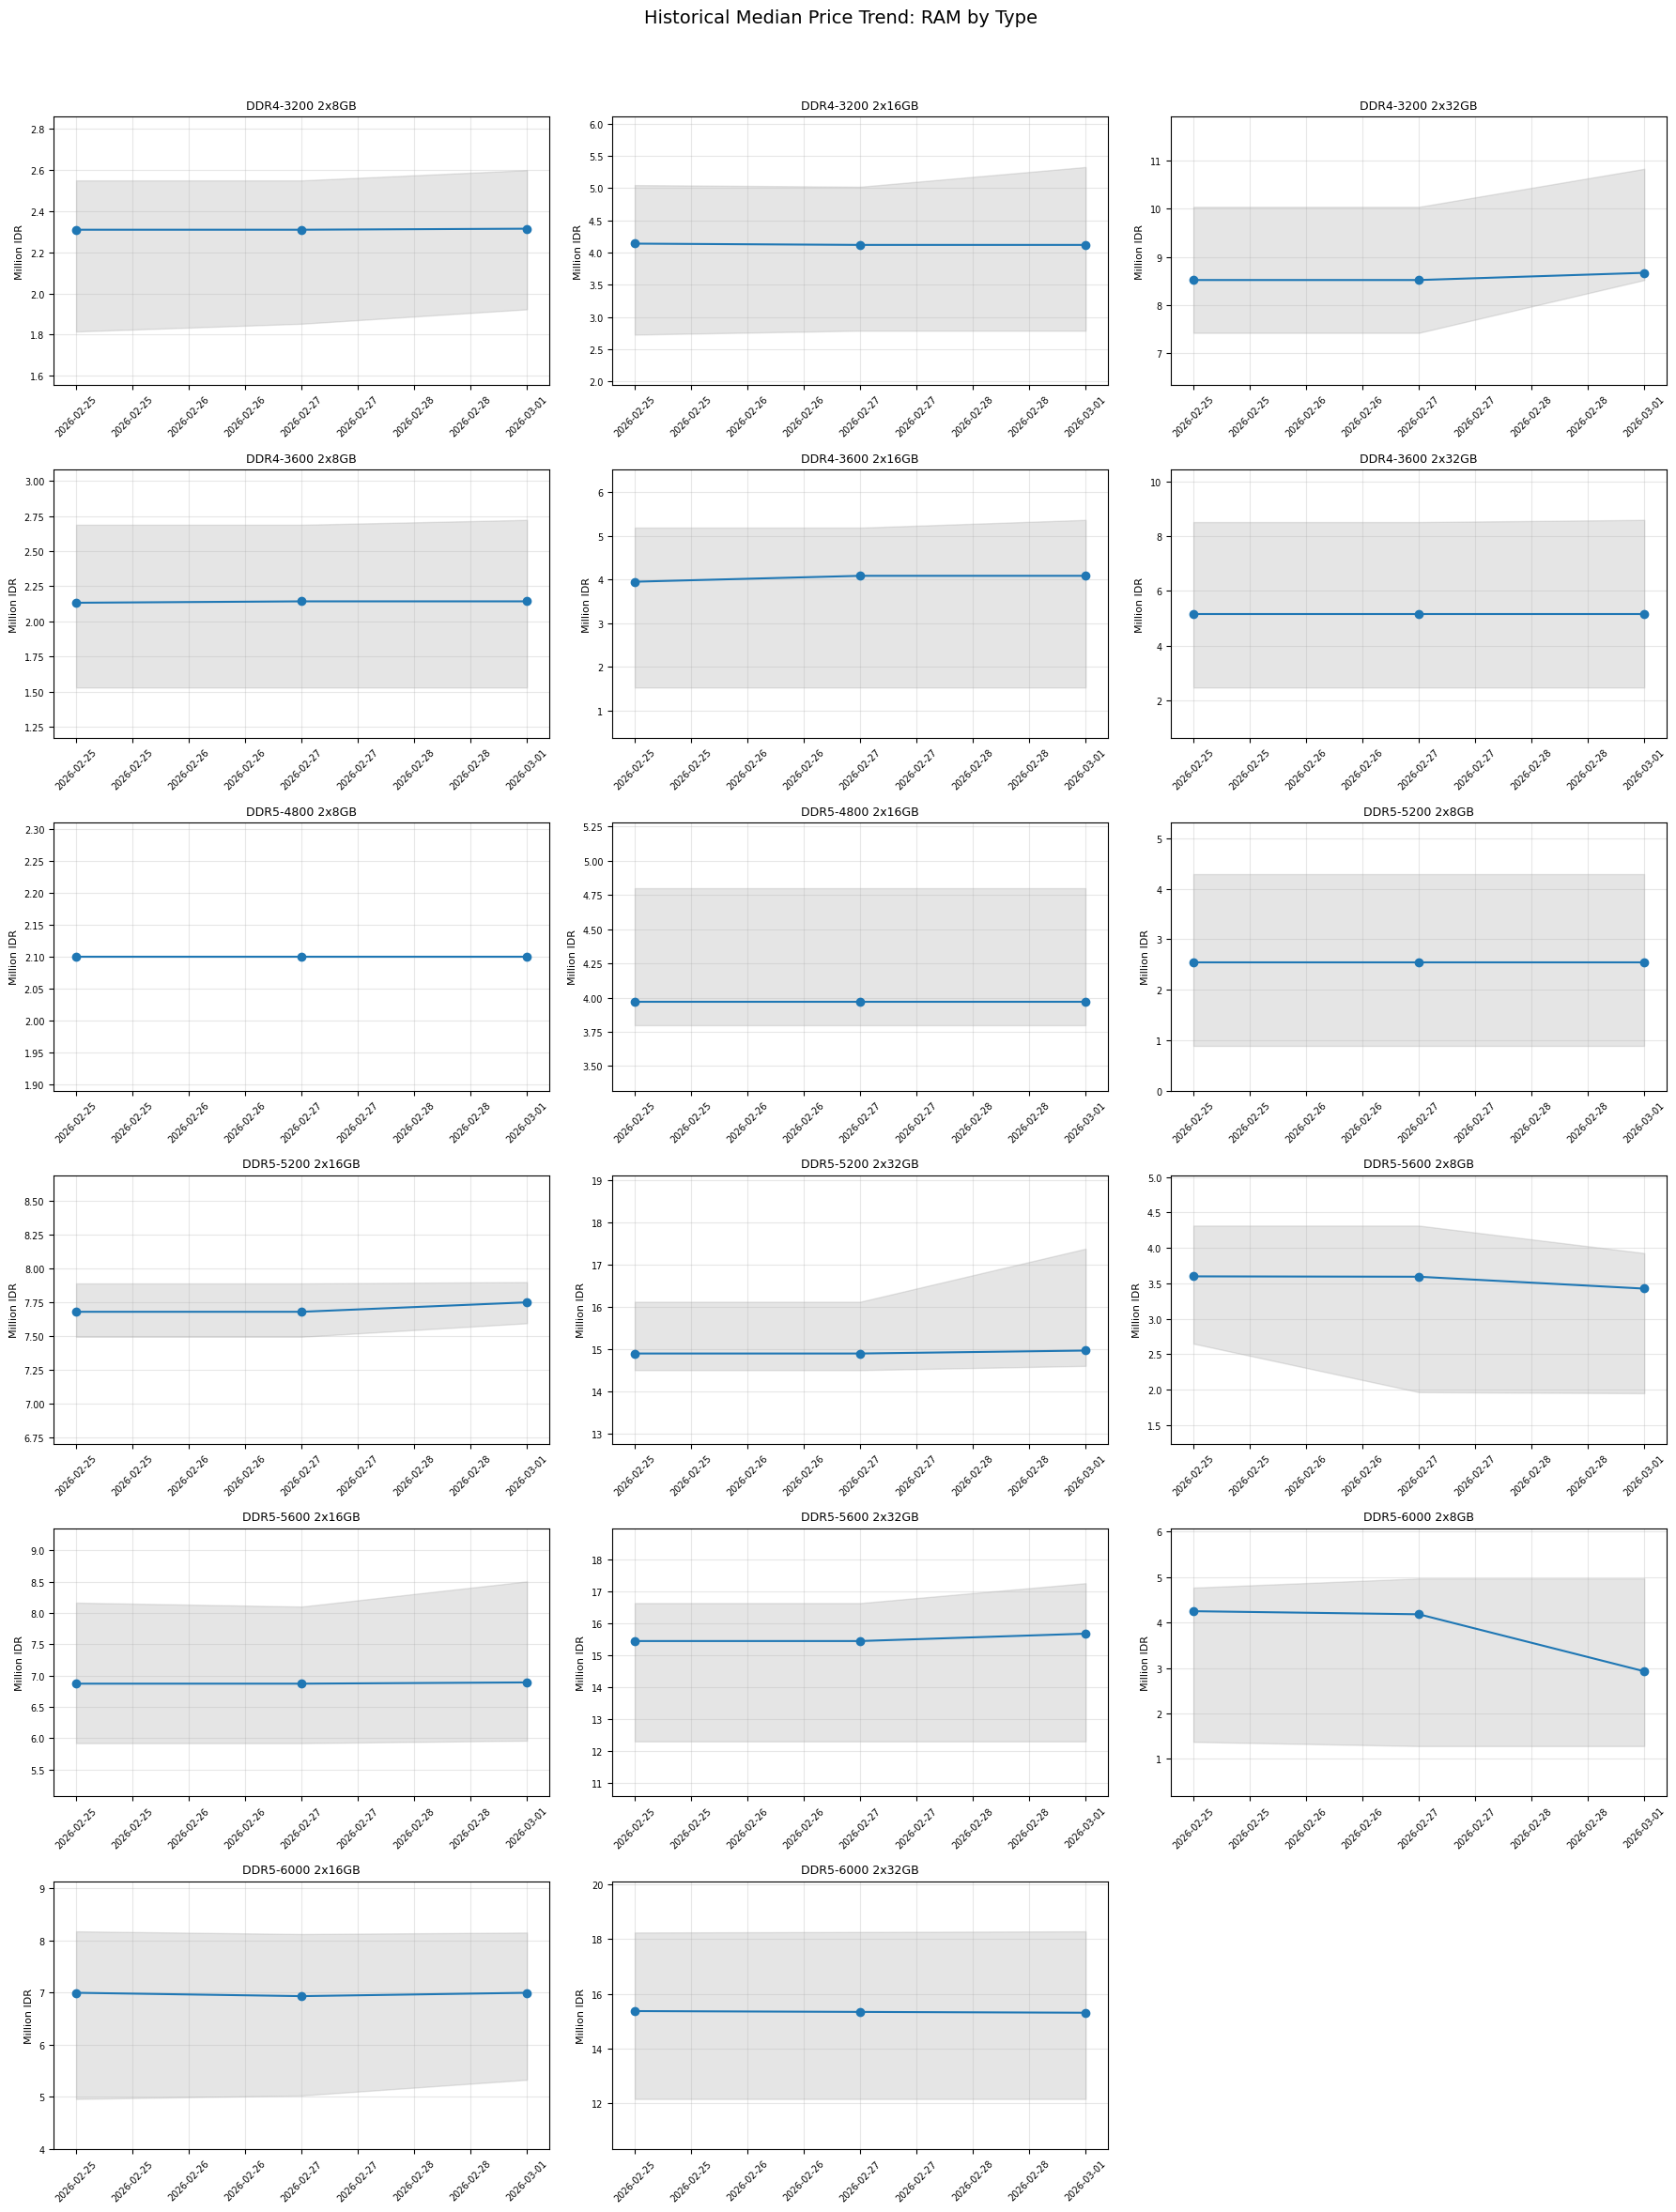

In [44]:
# Historical trend: RAM by type
def ram_sort_key(t):
    m = re.match(r'DDR(\d)-(\d+) (\d+)x(\d+)GB', t)
    gen, speed, count, size = int(m[1]), int(m[2]), int(m[3]), int(m[4])
    return (gen, speed, count * size)

ram_medians: dict[str, list[float | None]] = defaultdict(list)
ram_q1: dict[str, list[float | None]] = defaultdict(list)
ram_q3: dict[str, list[float | None]] = defaultdict(list)
all_ram_labels: set[str] = set()

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.RAM, [])
    prodinfos = [result_to_product_info(x.title + ' ' + (x.detail or ''), ProductCategory.RAM, int(x.price)) for x in prods]
    infos = [x for x in prodinfos if x is not None and isinstance(x.details, RAMInfo)]
    prices_by_type: dict[str, list[int]] = defaultdict(list)
    for item in infos:
        prices_by_type[item.details.ram_type.value].append(item.price)
    all_ram_labels.update(prices_by_type.keys())
    for label in all_ram_labels:
        if label in prices_by_type:
            prices = prices_by_type[label]
            ram_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                ram_q1[label].append(qs[0] / 1e6)
                ram_q3[label].append(qs[2] / 1e6)
            else:
                ram_q1[label].append(prices[0] / 1e6)
                ram_q3[label].append(prices[0] / 1e6)
        else:
            ram_medians[label].append(None)
            ram_q1[label].append(None)
            ram_q3[label].append(None)

sorted_ram_labels = sorted(all_ram_labels, key=ram_sort_key)
plot_historical_trend(dates, ram_medians, ram_q1, ram_q3, sorted_ram_labels,
    'Historical Median Price Trend: RAM by Type', 'RAM Type')

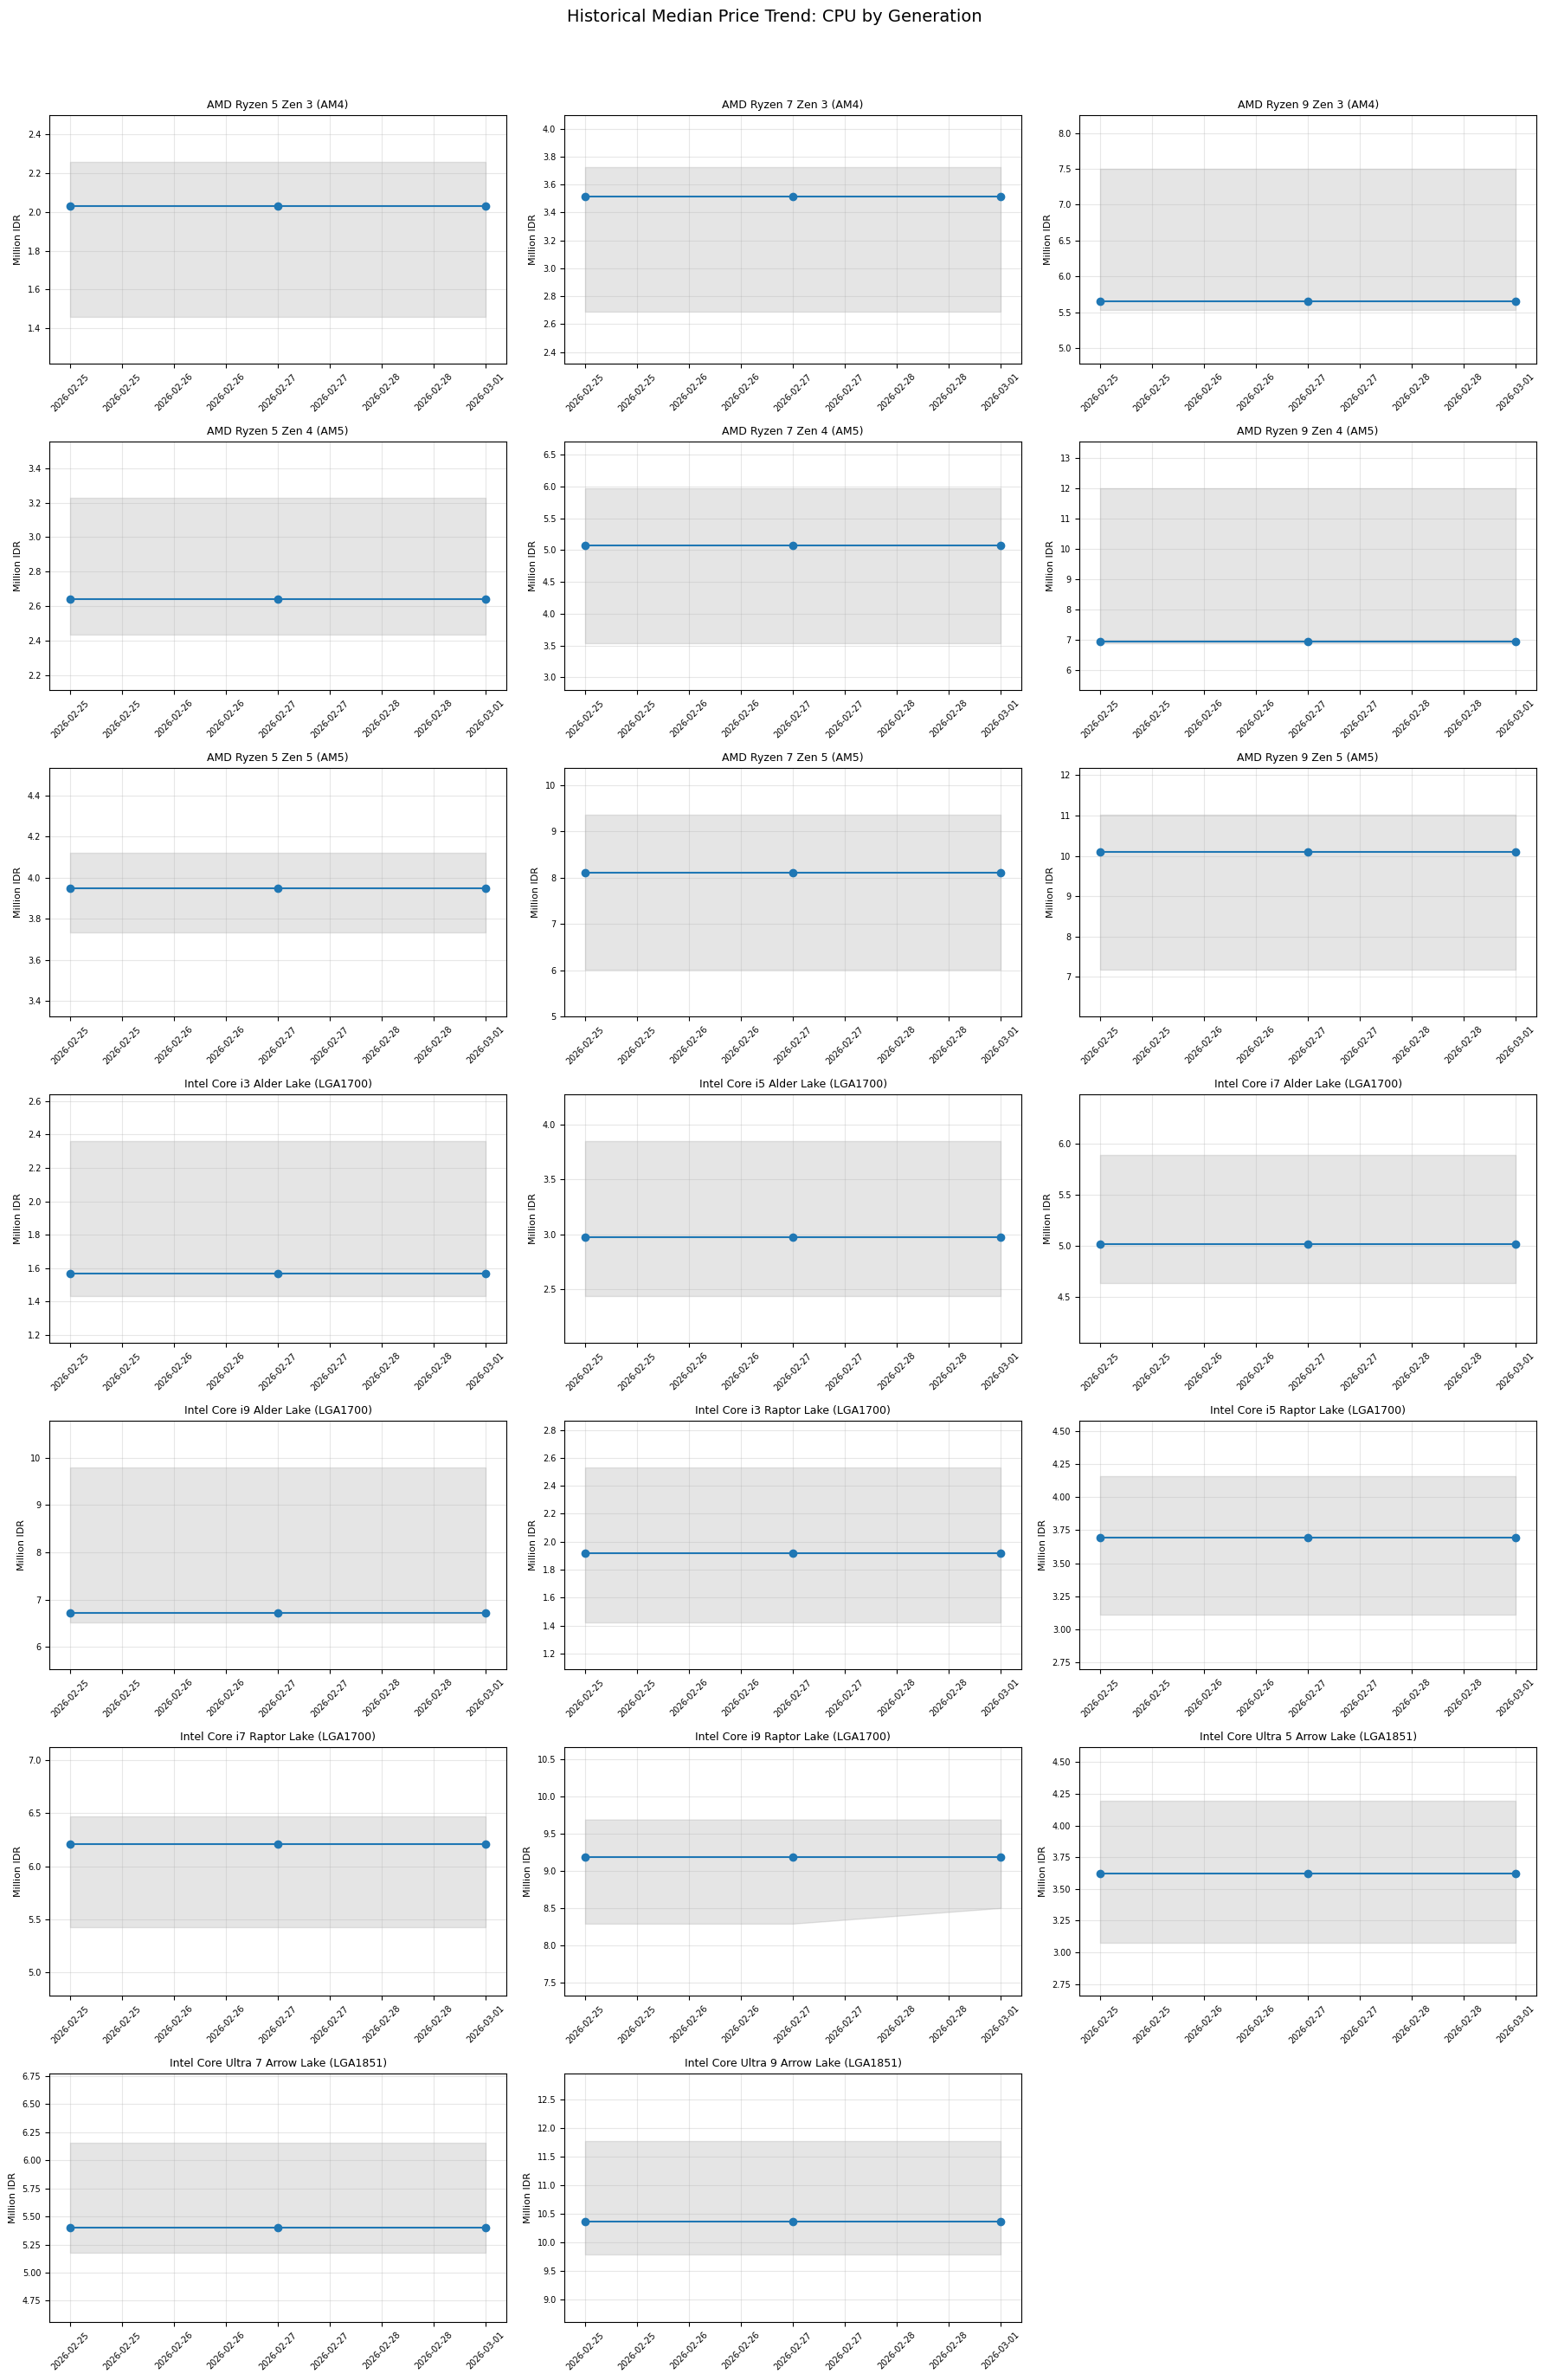

In [45]:
# Historical trend: CPU by generation/tier
def get_cpu_tier(title):
    for pattern, label in [
        (r'Core Ultra 9', 'Core Ultra 9'), (r'Core Ultra 7', 'Core Ultra 7'),
        (r'Core Ultra 5', 'Core Ultra 5'),
        (r'Ryzen 9', 'Ryzen 9'), (r'Ryzen 7', 'Ryzen 7'), (r'Ryzen 5', 'Ryzen 5'),
        (r'i9[- ]|Core i9', 'Core i9'), (r'i7[- ]|Core i7', 'Core i7'),
        (r'i5[- ]|Core i5', 'Core i5'), (r'i3[- ]|Core i3', 'Core i3'),
    ]:
        if re.search(pattern, title, re.IGNORECASE):
            return label
    return None

GEN_LABELS = {
    CPUGeneration.AMD_AM4: 'Zen 3 (AM4)',
    CPUGeneration.AMD_AM5_Zen4: 'Zen 4 (AM5)',
    CPUGeneration.AMD_AM5_Zen5: 'Zen 5 (AM5)',
    CPUGeneration.Intel_LGA1700_AlderLake: 'Alder Lake (LGA1700)',
    CPUGeneration.Intel_LGA1700_RaptorLake: 'Raptor Lake (LGA1700)',
    CPUGeneration.Intel_LGA1851: 'Arrow Lake (LGA1851)',
}

CPU_CATEGORIES = [
    'AMD Ryzen 5 Zen 3 (AM4)', 'AMD Ryzen 7 Zen 3 (AM4)', 'AMD Ryzen 9 Zen 3 (AM4)',
    'AMD Ryzen 5 Zen 4 (AM5)', 'AMD Ryzen 7 Zen 4 (AM5)', 'AMD Ryzen 9 Zen 4 (AM5)',
    'AMD Ryzen 5 Zen 5 (AM5)', 'AMD Ryzen 7 Zen 5 (AM5)', 'AMD Ryzen 9 Zen 5 (AM5)',
    'Intel Core i3 Alder Lake (LGA1700)', 'Intel Core i5 Alder Lake (LGA1700)',
    'Intel Core i7 Alder Lake (LGA1700)', 'Intel Core i9 Alder Lake (LGA1700)',
    'Intel Core i3 Raptor Lake (LGA1700)', 'Intel Core i5 Raptor Lake (LGA1700)',
    'Intel Core i7 Raptor Lake (LGA1700)', 'Intel Core i9 Raptor Lake (LGA1700)',
    'Intel Core Ultra 5 Arrow Lake (LGA1851)', 'Intel Core Ultra 7 Arrow Lake (LGA1851)',
    'Intel Core Ultra 9 Arrow Lake (LGA1851)',
]

cpu_medians: dict[str, list[float | None]] = defaultdict(list)
cpu_q1: dict[str, list[float | None]] = defaultdict(list)
cpu_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.PROCESSOR, [])
    prices_by_cpu: dict[str, list[int]] = defaultdict(list)
    for x in prods:
        title = x.title + ' ' + (x.detail or '')
        info = result_to_product_info(title, ProductCategory.PROCESSOR, int(x.price))
        if info is None or not isinstance(info.details, CPUInfo):
            continue
        tier = get_cpu_tier(title)
        if tier is None:
            continue
        gen_label = GEN_LABELS.get(info.details.generation, '')
        brand_label = 'AMD' if info.details.brand == Brand.AMD else 'Intel'
        label = f'{brand_label} {tier} {gen_label}'
        if label in CPU_CATEGORIES:
            prices_by_cpu[label].append(info.price)
    for label in CPU_CATEGORIES:
        if label in prices_by_cpu:
            prices = prices_by_cpu[label]
            cpu_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                cpu_q1[label].append(qs[0] / 1e6)
                cpu_q3[label].append(qs[2] / 1e6)
            else:
                cpu_q1[label].append(prices[0] / 1e6)
                cpu_q3[label].append(prices[0] / 1e6)
        else:
            cpu_medians[label].append(None)
            cpu_q1[label].append(None)
            cpu_q3[label].append(None)

plot_historical_trend(dates, cpu_medians, cpu_q1, cpu_q3, CPU_CATEGORIES,
    'Historical Median Price Trend: CPU by Generation', 'CPU Category')

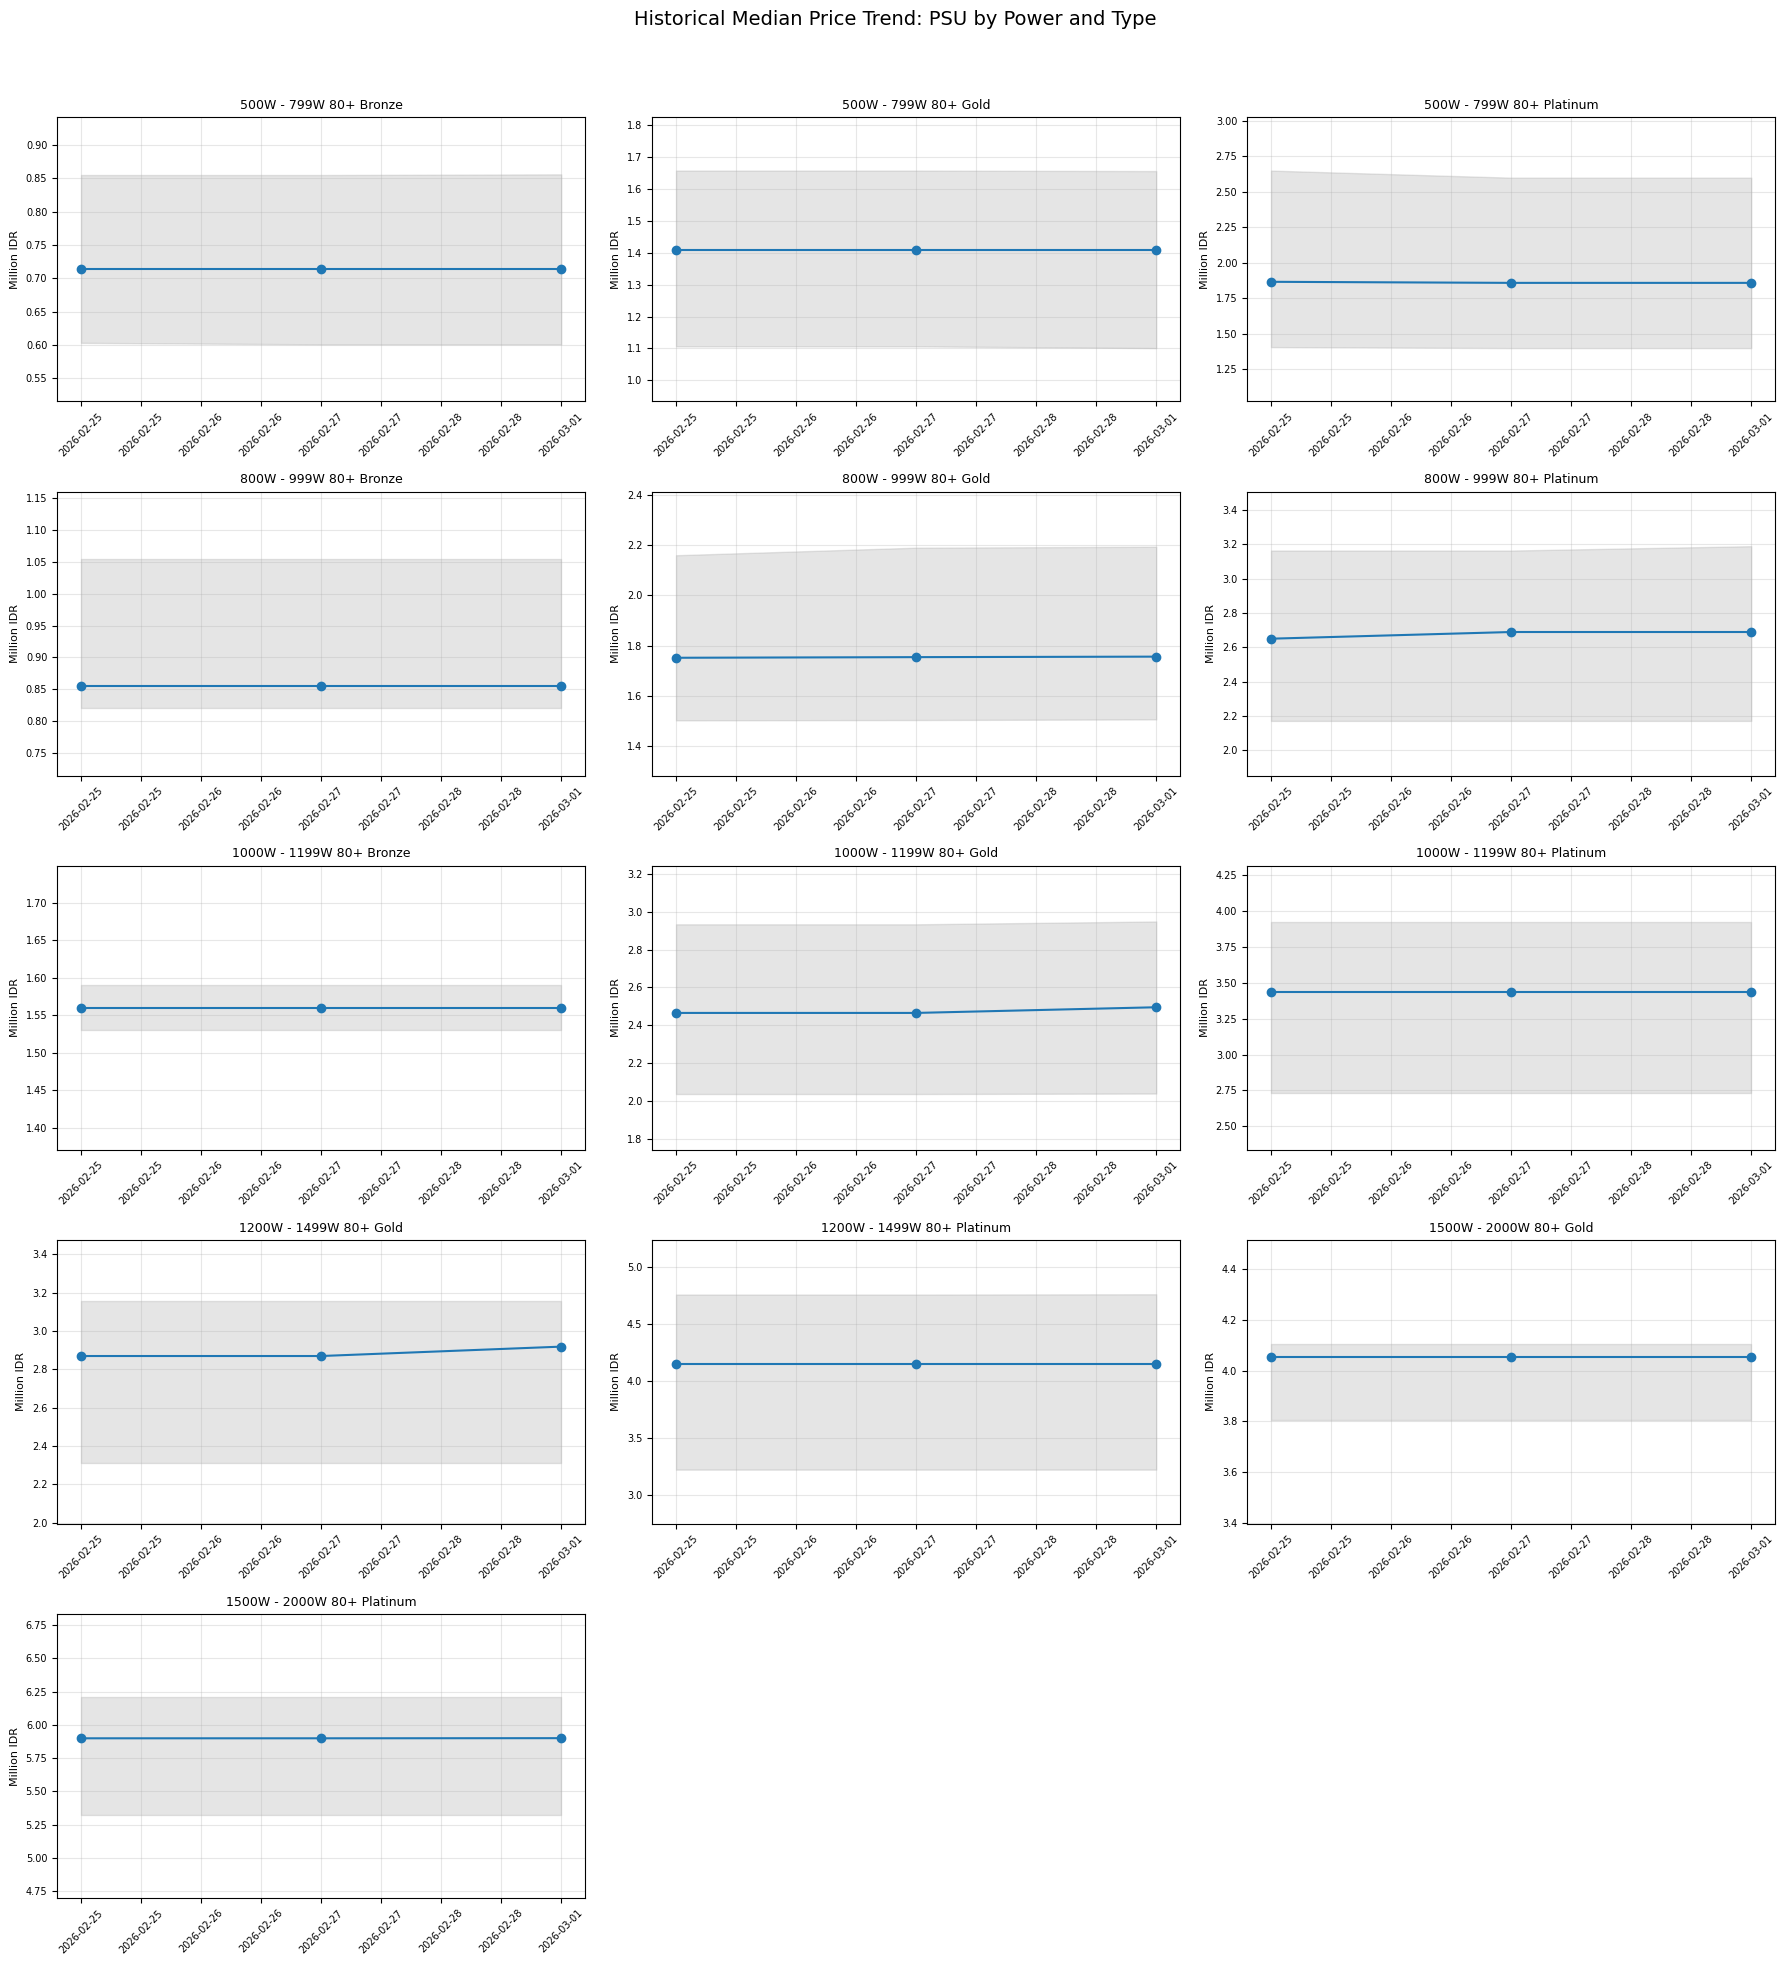

In [46]:
# Historical trend: PSU by power and type
PSU_CATEGORIES = [
    '500W - 799W 80+ Bronze', '500W - 799W 80+ Gold', '500W - 799W 80+ Platinum',
    '800W - 999W 80+ Bronze', '800W - 999W 80+ Gold', '800W - 999W 80+ Platinum',
    '1000W - 1199W 80+ Bronze', '1000W - 1199W 80+ Gold', '1000W - 1199W 80+ Platinum',
    '1200W - 1499W 80+ Gold', '1200W - 1499W 80+ Platinum',
    '1500W - 2000W 80+ Gold', '1500W - 2000W 80+ Platinum',
]

psu_medians: dict[str, list[float | None]] = defaultdict(list)
psu_q1: dict[str, list[float | None]] = defaultdict(list)
psu_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.PSU, [])
    prices_by_psu: dict[str, list[int]] = defaultdict(list)
    for x in prods:
        title = x.title + ' ' + (x.detail or '')
        info = result_to_product_info(title, ProductCategory.PSU, int(x.price))
        if info is None or not isinstance(info.details, PSUInfo):
            continue
        try:
            power_range = info.details.power_range
        except ValueError:
            continue
        label = f'{power_range.value} 80+ {info.details.psu_type.value}'
        if label in PSU_CATEGORIES:
            prices_by_psu[label].append(info.price)
    for label in PSU_CATEGORIES:
        if label in prices_by_psu:
            prices = prices_by_psu[label]
            psu_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                psu_q1[label].append(qs[0] / 1e6)
                psu_q3[label].append(qs[2] / 1e6)
            else:
                psu_q1[label].append(prices[0] / 1e6)
                psu_q3[label].append(prices[0] / 1e6)
        else:
            psu_medians[label].append(None)
            psu_q1[label].append(None)
            psu_q3[label].append(None)

plot_historical_trend(dates, psu_medians, psu_q1, psu_q3, PSU_CATEGORIES,
    'Historical Median Price Trend: PSU by Power and Type', 'PSU Category')

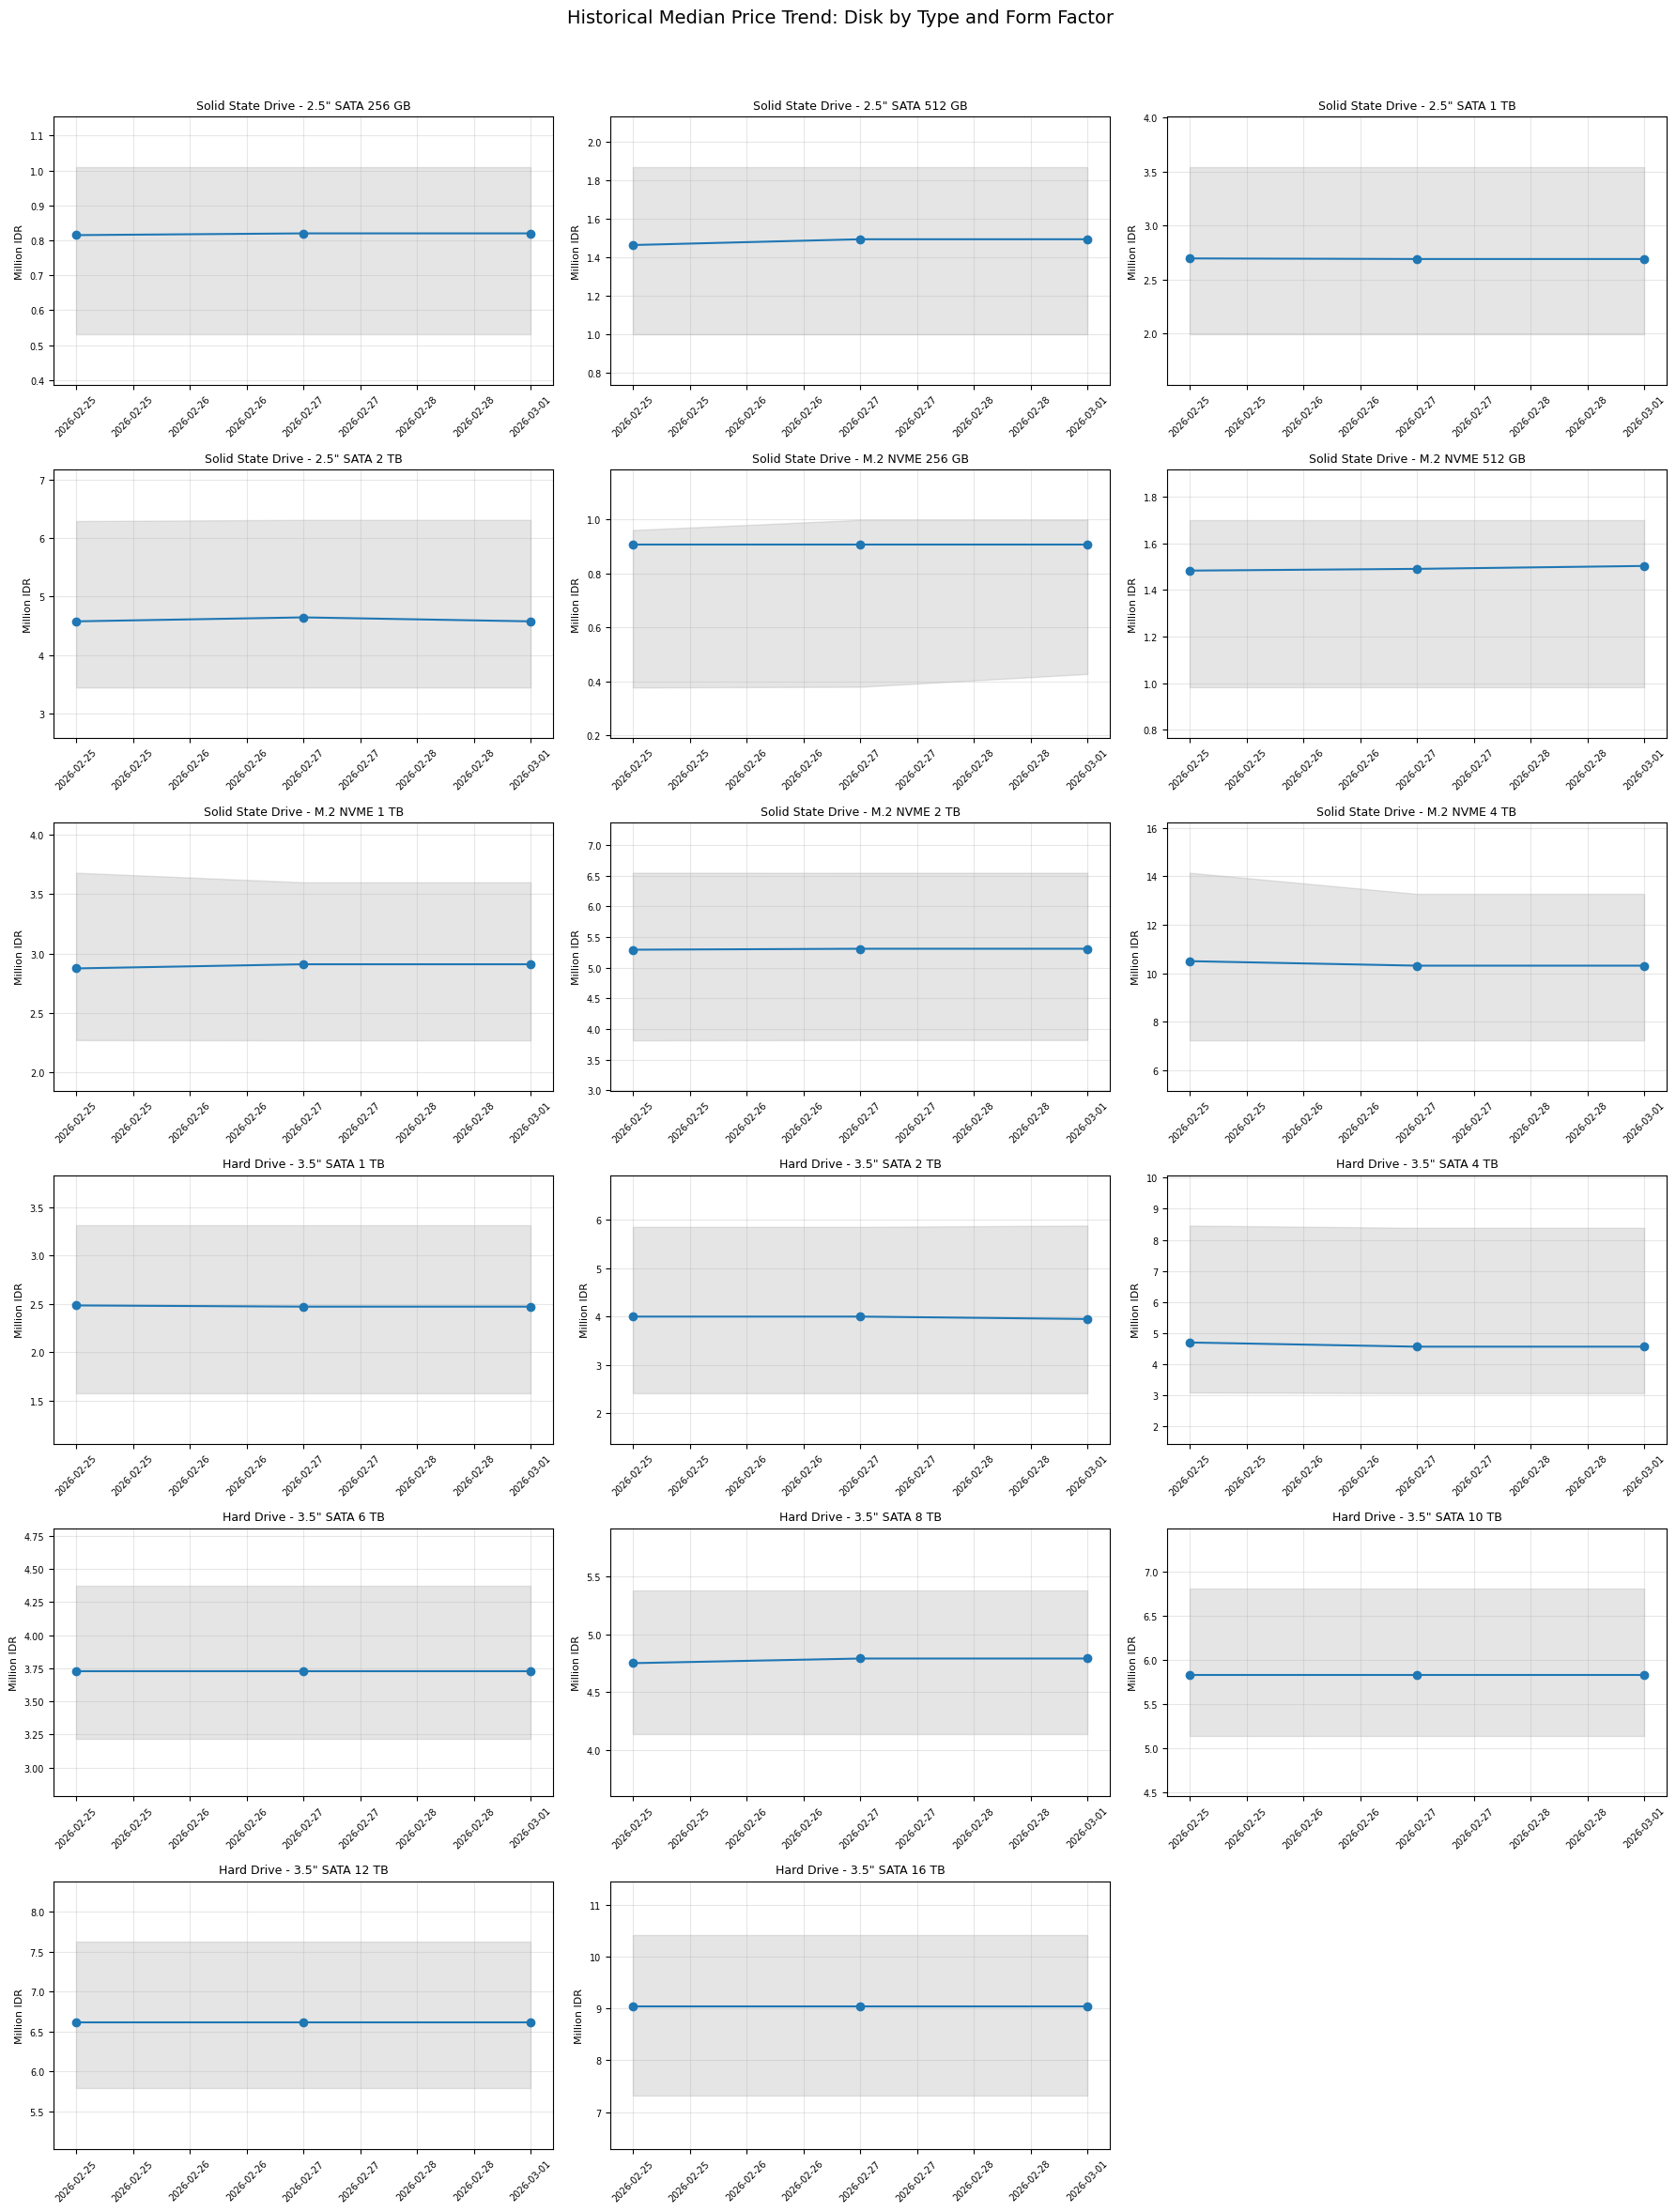

In [47]:
# Historical trend: Disk (SSD + HDD) by type and form factor
def format_capacity(capacity_gb):
    if capacity_gb >= 1000:
        return f'{capacity_gb // 1000} TB'
    return f'{capacity_gb} GB'

DISK_TYPE_LABELS = {
    DiskType.SSD: 'Solid State Drive',
    DiskType.HDD: 'Hard Drive',
}

DISK_CATEGORIES = [
    'Solid State Drive - 2.5\" SATA 256 GB', 'Solid State Drive - 2.5\" SATA 512 GB',
    'Solid State Drive - 2.5\" SATA 1 TB', 'Solid State Drive - 2.5\" SATA 2 TB',
    'Solid State Drive - M.2 NVME 256 GB', 'Solid State Drive - M.2 NVME 512 GB',
    'Solid State Drive - M.2 NVME 1 TB', 'Solid State Drive - M.2 NVME 2 TB',
    'Solid State Drive - M.2 NVME 4 TB',
    'Hard Drive - 3.5\" SATA 1 TB', 'Hard Drive - 3.5\" SATA 2 TB',
    'Hard Drive - 3.5\" SATA 4 TB', 'Hard Drive - 3.5\" SATA 6 TB',
    'Hard Drive - 3.5\" SATA 8 TB', 'Hard Drive - 3.5\" SATA 10 TB',
    'Hard Drive - 3.5\" SATA 12 TB', 'Hard Drive - 3.5\" SATA 16 TB',
]

disk_medians: dict[str, list[float | None]] = defaultdict(list)
disk_q1: dict[str, list[float | None]] = defaultdict(list)
disk_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    ssd_prods = all_data_by_date[dt].get(ProductCategory.SSD, [])
    hdd_prods = all_data_by_date[dt].get(ProductCategory.HARDDISK, [])
    prices_by_disk: dict[str, list[int]] = defaultdict(list)
    for cat, prods in [(ProductCategory.SSD, ssd_prods), (ProductCategory.HARDDISK, hdd_prods)]:
        for x in prods:
            title = x.title + ' ' + (x.detail or '')
            info = result_to_product_info(title, cat, int(x.price))
            if info is None or not isinstance(info.details, DiskInfo):
                continue
            d = info.details
            type_label = DISK_TYPE_LABELS[d.disk_type]
            label = f'{type_label} - {d.form_factor.value} {format_capacity(d.capacity_gb)}'
            if label in DISK_CATEGORIES:
                prices_by_disk[label].append(info.price)
    for label in DISK_CATEGORIES:
        if label in prices_by_disk:
            prices = prices_by_disk[label]
            disk_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                disk_q1[label].append(qs[0] / 1e6)
                disk_q3[label].append(qs[2] / 1e6)
            else:
                disk_q1[label].append(prices[0] / 1e6)
                disk_q3[label].append(prices[0] / 1e6)
        else:
            disk_medians[label].append(None)
            disk_q1[label].append(None)
            disk_q3[label].append(None)

plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, DISK_CATEGORIES,
    'Historical Median Price Trend: Disk by Type and Form Factor', 'Disk Category')

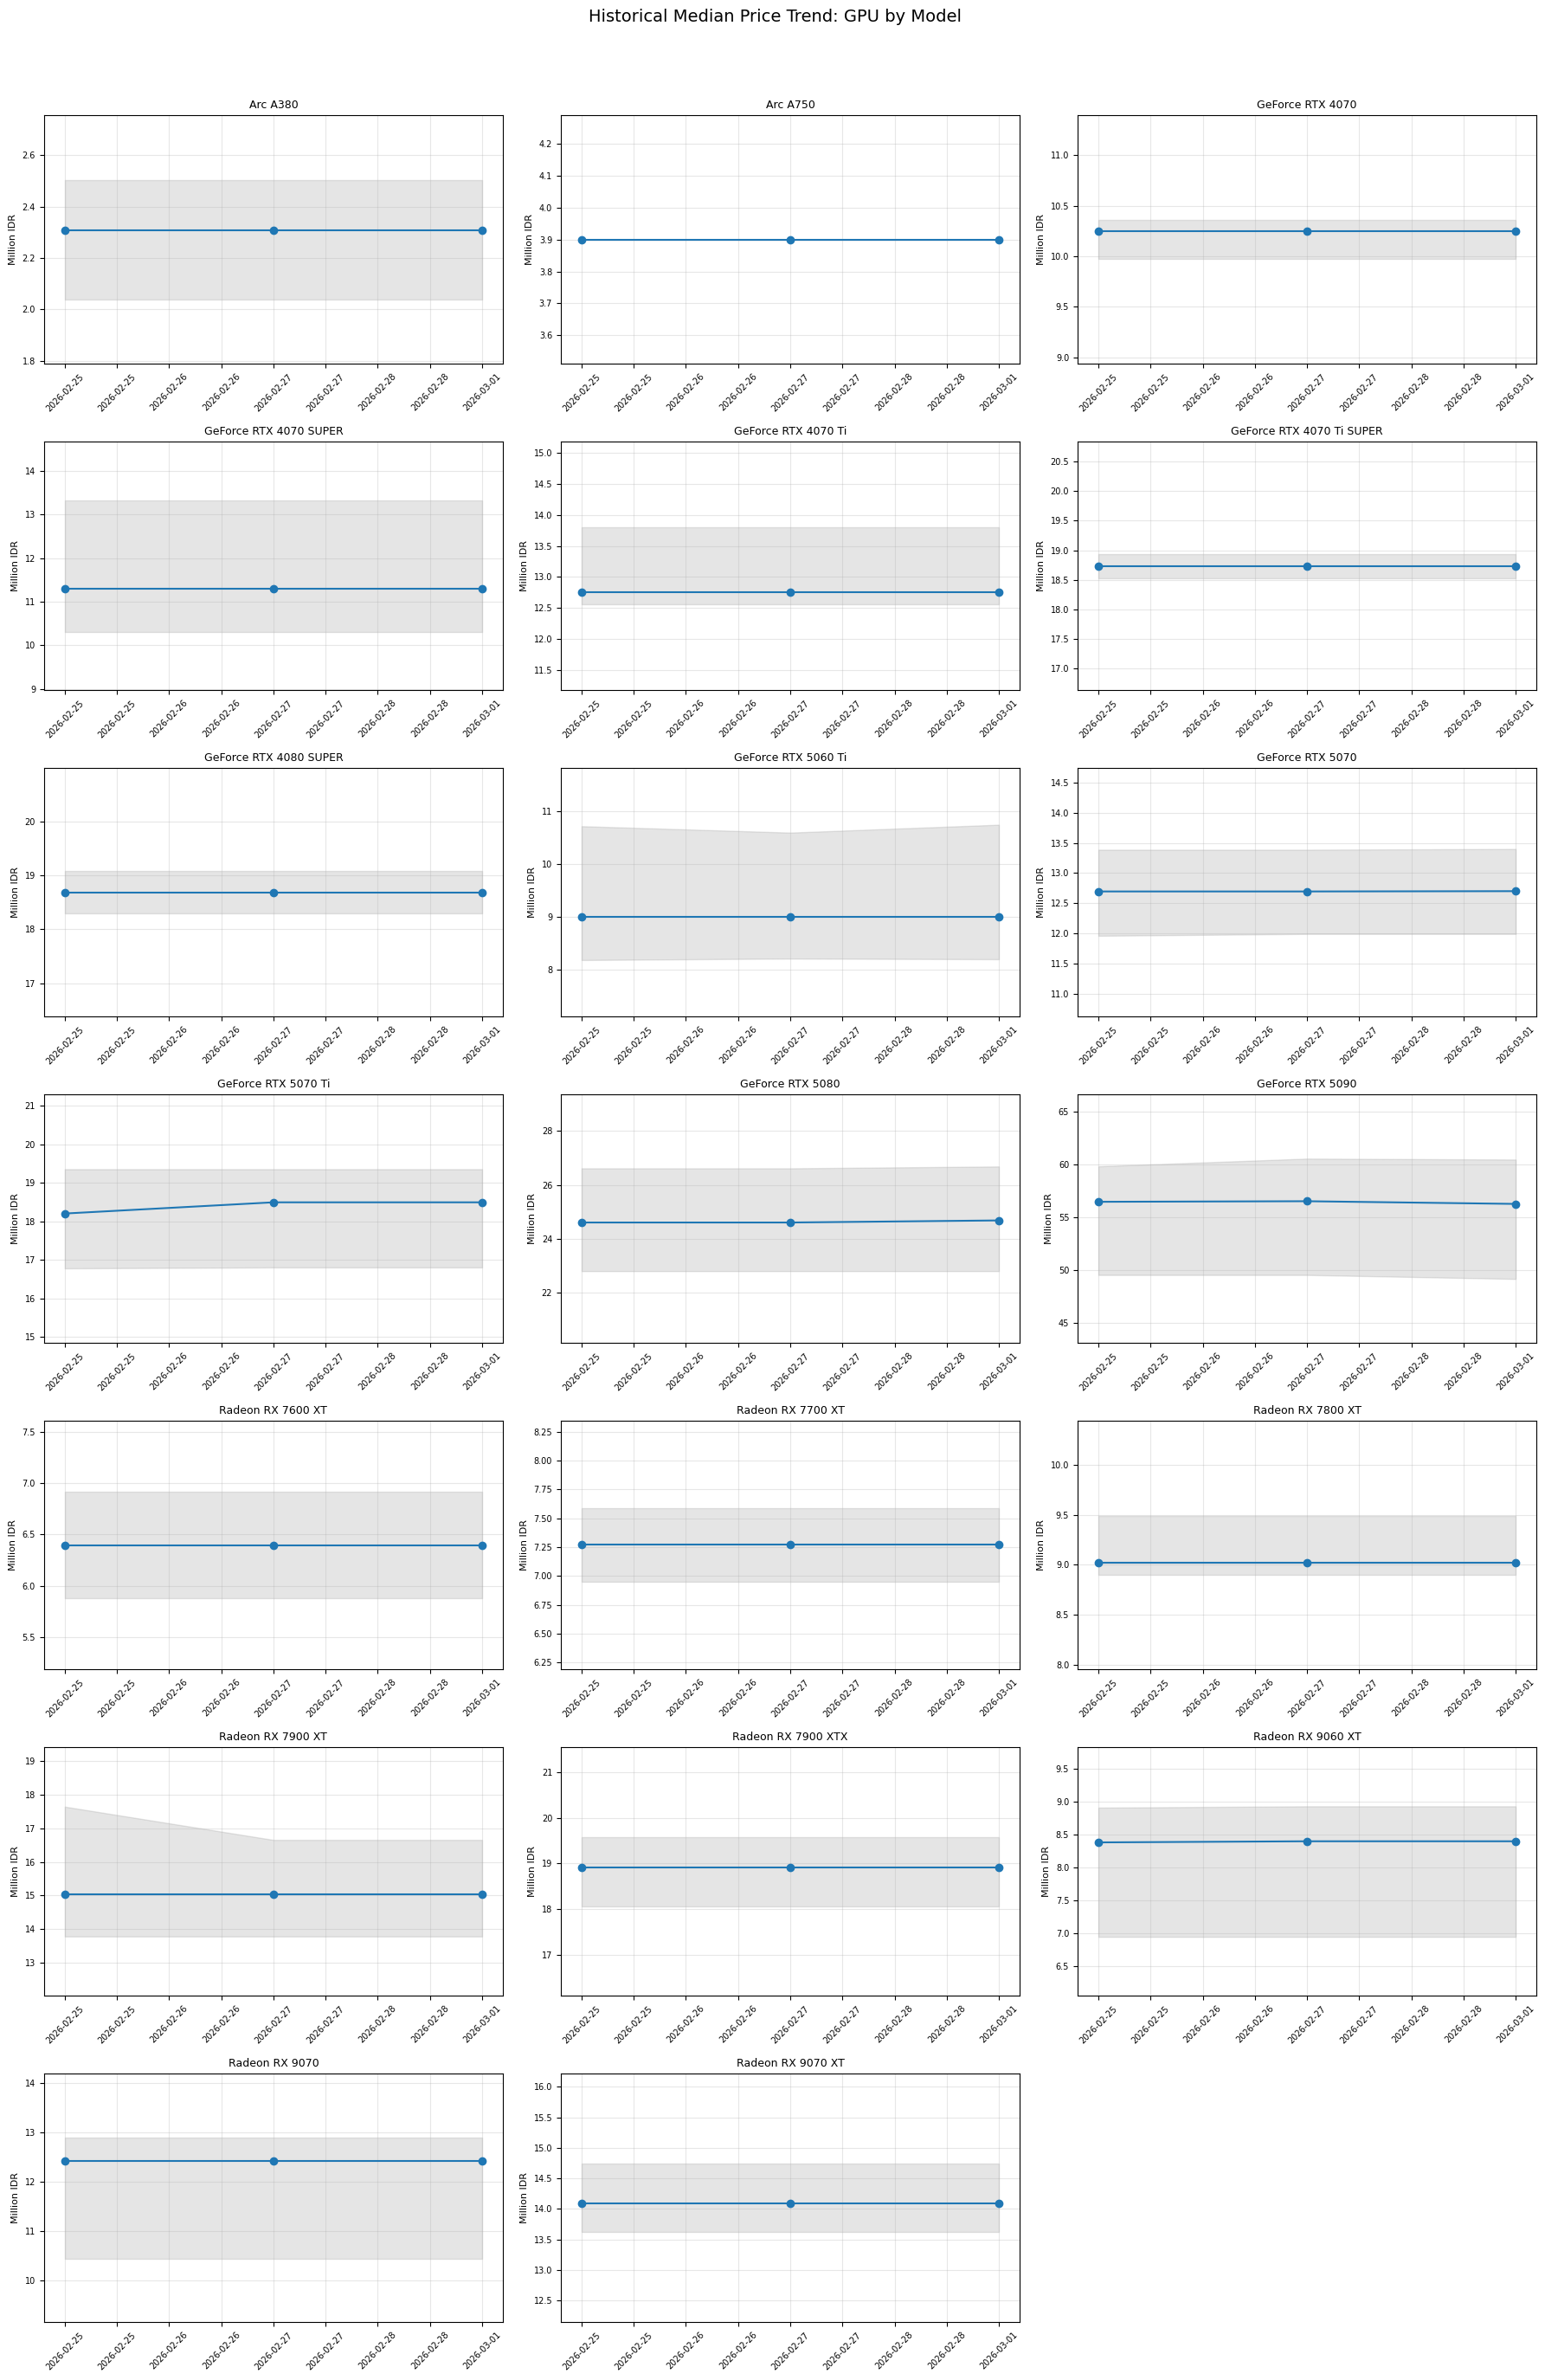

In [48]:
# Historical trend: GPU by model
GPU_MODELS = [
    'GeForce RTX 4070 Ti SUPER', 'GeForce RTX 4070 Ti', 'GeForce RTX 4070 SUPER',
    'GeForce RTX 4070', 'GeForce RTX 4080 SUPER', 'GeForce RTX 4080', 'GeForce RTX 4090',
    'GeForce RTX 5060 Ti', 'GeForce RTX 5070 Ti', 'GeForce RTX 5070',
    'GeForce RTX 5080', 'GeForce RTX 5090',
    'Radeon RX 7600 XT', 'Radeon RX 7700 XT', 'Radeon RX 7800 XT',
    'Radeon RX 7900 XTX', 'Radeon RX 7900 XT',
    'Radeon RX 9060 XT', 'Radeon RX 9070 XT', 'Radeon RX 9070',
    'Arc A770', 'Arc A750', 'Arc A380',
]

GPU_DISPLAY_ORDER = [
    'Arc A380', 'Arc A750', 'Arc A770',
    'GeForce RTX 4070', 'GeForce RTX 4070 SUPER', 'GeForce RTX 4070 Ti',
    'GeForce RTX 4070 Ti SUPER', 'GeForce RTX 4080', 'GeForce RTX 4080 SUPER',
    'GeForce RTX 4090', 'GeForce RTX 5060 Ti', 'GeForce RTX 5070',
    'GeForce RTX 5070 Ti', 'GeForce RTX 5080', 'GeForce RTX 5090',
    'Radeon RX 7600 XT', 'Radeon RX 7700 XT', 'Radeon RX 7800 XT',
    'Radeon RX 7900 XT', 'Radeon RX 7900 XTX',
    'Radeon RX 9060 XT', 'Radeon RX 9070', 'Radeon RX 9070 XT',
]

def get_gpu_category(title):
    title_lower = title.lower()
    for model in GPU_MODELS:
        if model.lower() in title_lower:
            return model
    return None

gpu_medians: dict[str, list[float | None]] = defaultdict(list)
gpu_q1: dict[str, list[float | None]] = defaultdict(list)
gpu_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.VGA, [])
    prices_by_gpu: dict[str, list[int]] = defaultdict(list)
    for x in prods:
        title = x.title + ' ' + (x.detail or '')
        model = get_gpu_category(title)
        if model is None:
            continue
        prices_by_gpu[model].append(int(x.price))
    for label in GPU_DISPLAY_ORDER:
        if label in prices_by_gpu:
            prices = prices_by_gpu[label]
            gpu_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                gpu_q1[label].append(qs[0] / 1e6)
                gpu_q3[label].append(qs[2] / 1e6)
            else:
                gpu_q1[label].append(prices[0] / 1e6)
                gpu_q3[label].append(prices[0] / 1e6)
        else:
            gpu_medians[label].append(None)
            gpu_q1[label].append(None)
            gpu_q3[label].append(None)

plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, GPU_DISPLAY_ORDER,
    'Historical Median Price Trend: GPU by Model', 'GPU Model')